# 1. 建立T细胞大类

CD4、CD8、NKT和Cycling T合并为T cells，NK单独保留，共10类。参考细胞不删除、不均衡。比较原13类拟合后相加与10类参考重新拟合。

输入由prepare_coarse_tcells.py生成；新RCTD拟合通过run_coarse_tcells.R执行。本Notebook读取保存的预测，计算NNLS并复核结果。


In [1]:
from pathlib import Path
import json
import runpy
import pandas as pd
from IPython.display import display, Image, Markdown
root = Path("/Users/georicl/Documents/sc_sncell_github")
result_dir = root / "results/Wu2021_coarse_T_v1"
display(pd.read_csv(result_dir / "label_mapping.csv"))
display(pd.read_csv(result_dir / "reference_counts_by_type.csv"))


,original_label,reference_label
0,Endothelial,Endothelial
1,CAFs,CAFs
2,PVL,PVL
3,B-cells,B-cells
4,Plasmablasts,Plasmablasts
5,T cells CD8+,T cells
6,T cells CD4+,T cells
7,NK cells,NK cells
8,Cycling T-cells,T cells
9,NKT cells,T cells


,donor_id,reference_label,n_cells
0,CID4471,B-cells,99
1,CID4471,CAFs,1292
2,CID4471,Cancer Epithelial,212
3,CID4471,Endothelial,2778
4,CID4471,Myeloid,285
5,CID4471,NK cells,30
6,CID4471,Normal Epithelial,1966
7,CID4471,PVL,1285
8,CID4471,Plasmablasts,51
9,CID4471,T cells,611


# 2. 在相同模拟spot上比较

复用五位已经查看过结果的供者，共1502个spot。参考重拟合与细分后汇总使用同一组成真值；按供者、配方和深度分别评价。


donor_id method               approach  depth_fraction  mae_pp
 CID4067   RCTD      fine_fit_then_sum            0.25   2.337
 CID4067   RCTD      fine_fit_then_sum            1.00   1.923
 CID4067   RCTD coarse_reference_refit            0.25   2.018
 CID4067   RCTD coarse_reference_refit            1.00   1.615
 CID4067   NNLS      fine_fit_then_sum            0.25   5.904
 CID4067   NNLS      fine_fit_then_sum            1.00   5.592
 CID4067   NNLS coarse_reference_refit            0.25   5.834
 CID4067   NNLS coarse_reference_refit            1.00   5.785
 CID4463   RCTD      fine_fit_then_sum            0.25   1.190
 CID4463   RCTD      fine_fit_then_sum            1.00   1.067
 CID4463   RCTD coarse_reference_refit            0.25   1.581
 CID4463   RCTD coarse_reference_refit            1.00   1.517
 CID4463   NNLS      fine_fit_then_sum            0.25  11.516
 CID4463   NNLS      fine_fit_then_sum            1.00  11.654
 CID4463   NNLS coarse_reference_refit            0.25 

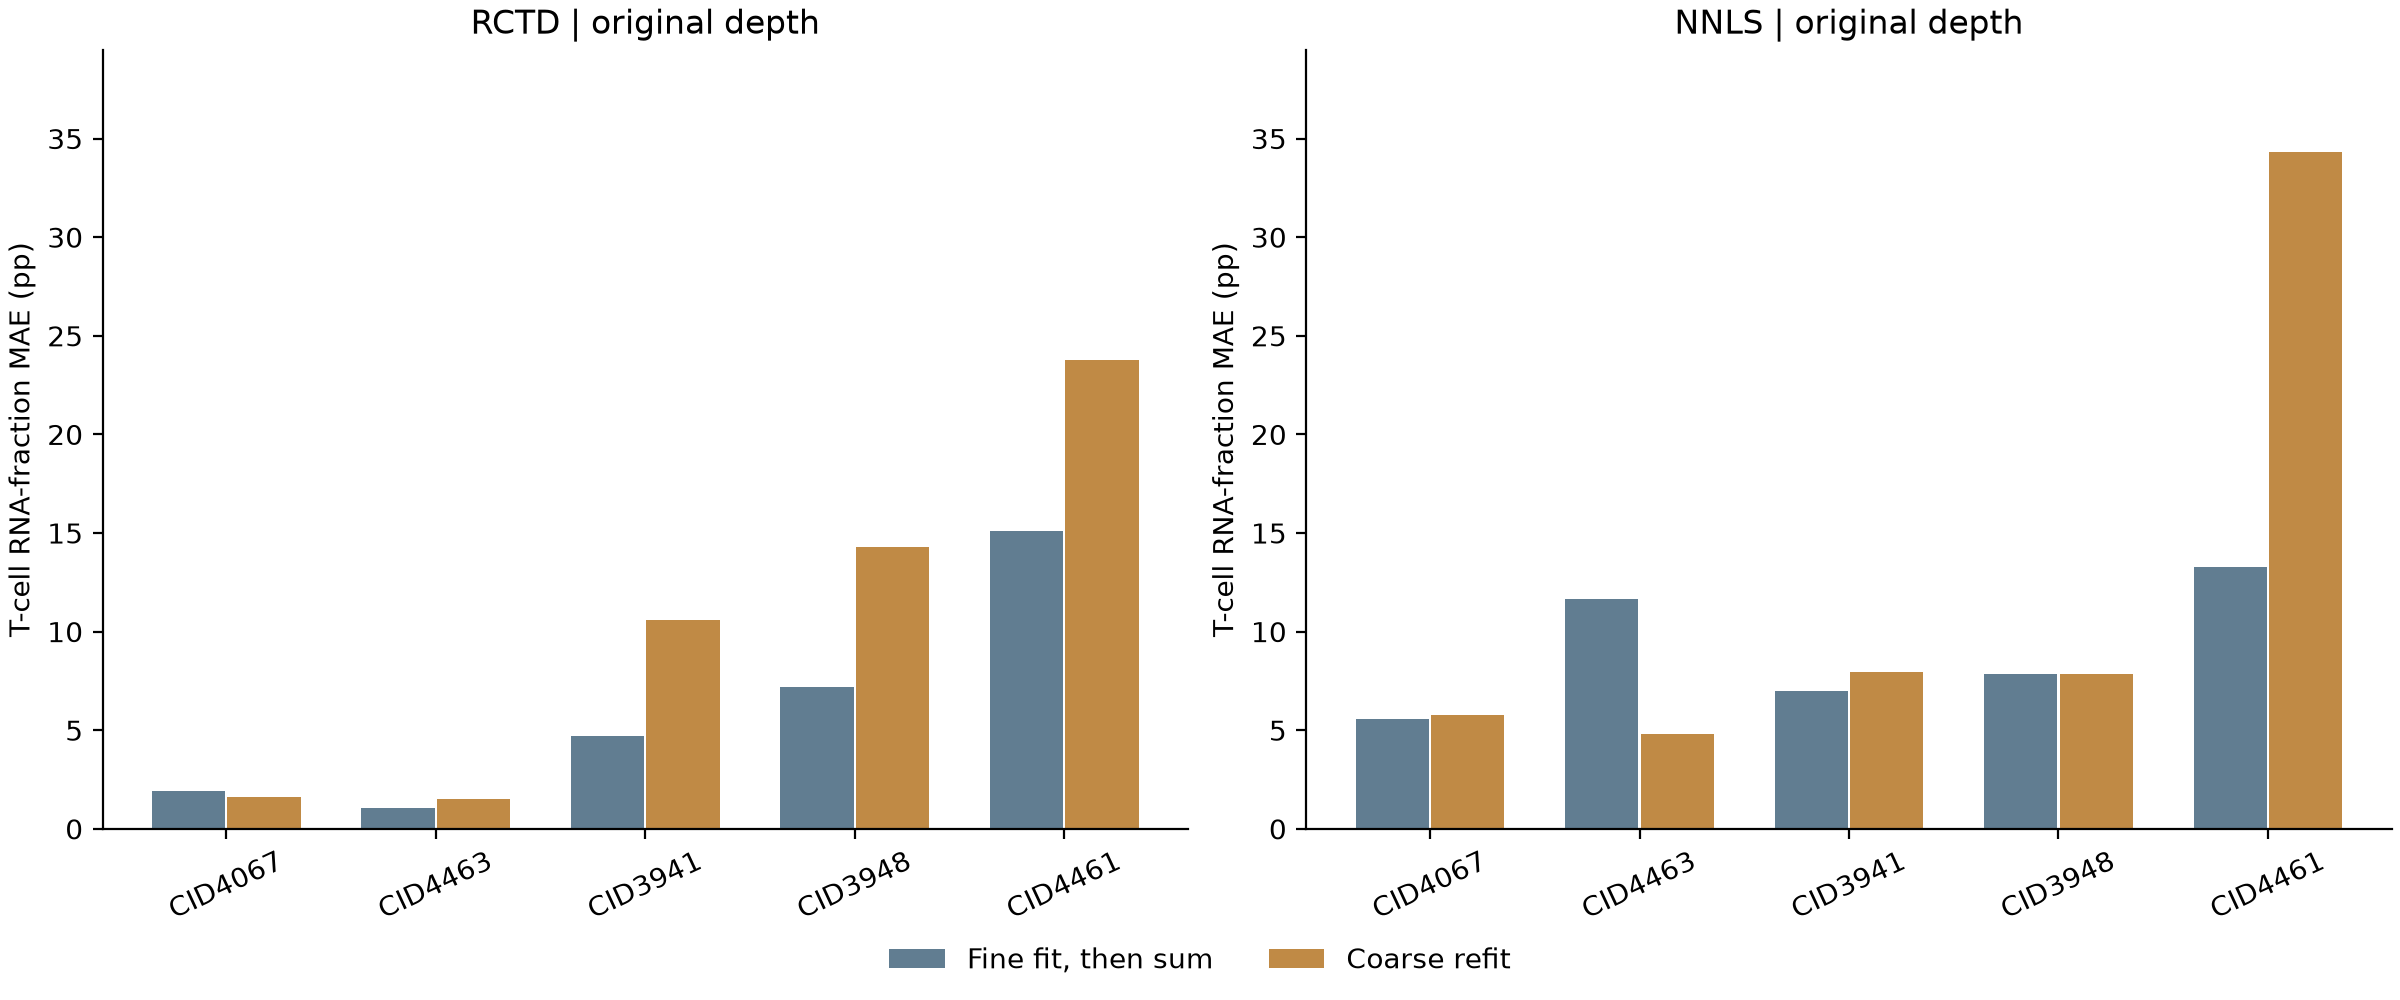

In [2]:
evaluation = runpy.run_path(str(root / "src/sc_sncell_github/evaluate_coarse_tcells.py"))
evaluation["main"]()
display(Image(filename=str(result_dir / "coarse_T_comparison.png")))


# 3. 检查原始纯群和NK负对照

保留原始CD4、CD8、NKT、Cycling T纯群名称，查看相加后的T细胞权重。NK纯群仍应预测为NK，不能因合并T细胞而忽略T/NK之间的误分配。


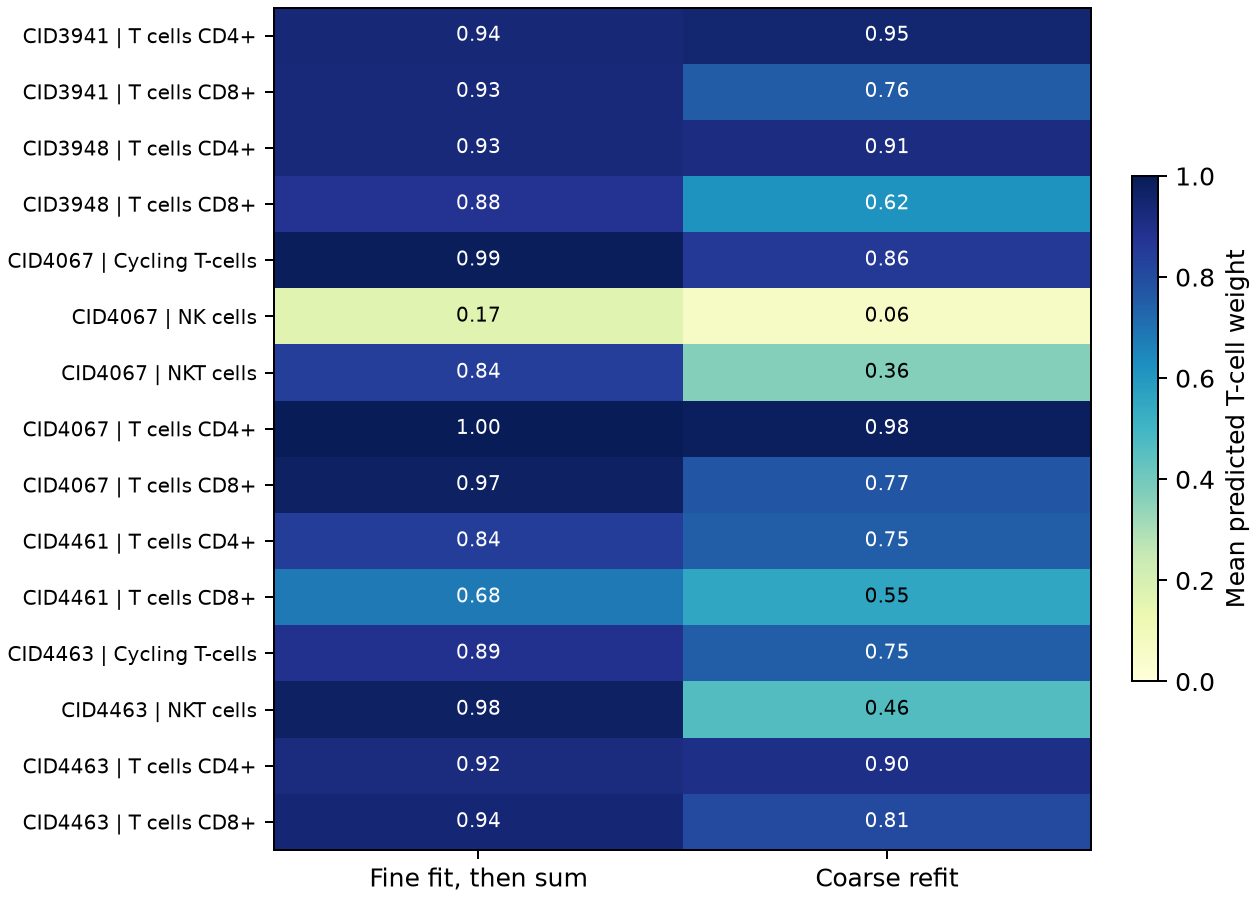

,donor_id,method,approach,depth_fraction,n_caf,cell_type,mae_pp,bias_pp
0,CID3941,RCTD,fine_fit_then_sum,0.25,0,T cells,7.218965,-7.218965
1,CID3941,RCTD,fine_fit_then_sum,0.25,0,CAFs,0.006143,0.006143
2,CID3941,RCTD,fine_fit_then_sum,0.25,1,T cells,6.501552,-5.501364
3,CID3941,RCTD,fine_fit_then_sum,0.25,1,CAFs,3.850288,-3.840992
4,CID3941,RCTD,fine_fit_then_sum,0.25,3,T cells,4.919312,-2.261720
...,...,...,...,...,...,...,...,...
139,CID4461,NNLS,coarse_reference_refit,1.00,0,CAFs,0.000000,0.000000
140,CID4461,NNLS,coarse_reference_refit,1.00,1,T cells,30.830067,-30.172524
141,CID4461,NNLS,coarse_reference_refit,1.00,1,CAFs,19.574916,-19.574916
142,CID4461,NNLS,coarse_reference_refit,1.00,3,T cells,19.474160,-12.951912


In [3]:
display(Image(filename=str(result_dir / "pure_T_and_NK_controls.png")))
display(pd.read_csv(result_dir / "caf_background_metrics.csv"))


# 4. 汇总CID4535已有空间图

此处使用原CID4535单供者参考的既有拟合，并非本轮双供者参考在空间数据上的新拟合。只将其结果按同一定义相加，便于逐点对照原图，同时汇总既有10次参考重抽样。


           spearman  top_retention
cell_type                         
CAFs       0.995441       0.959459
T cells    0.954175       0.865766


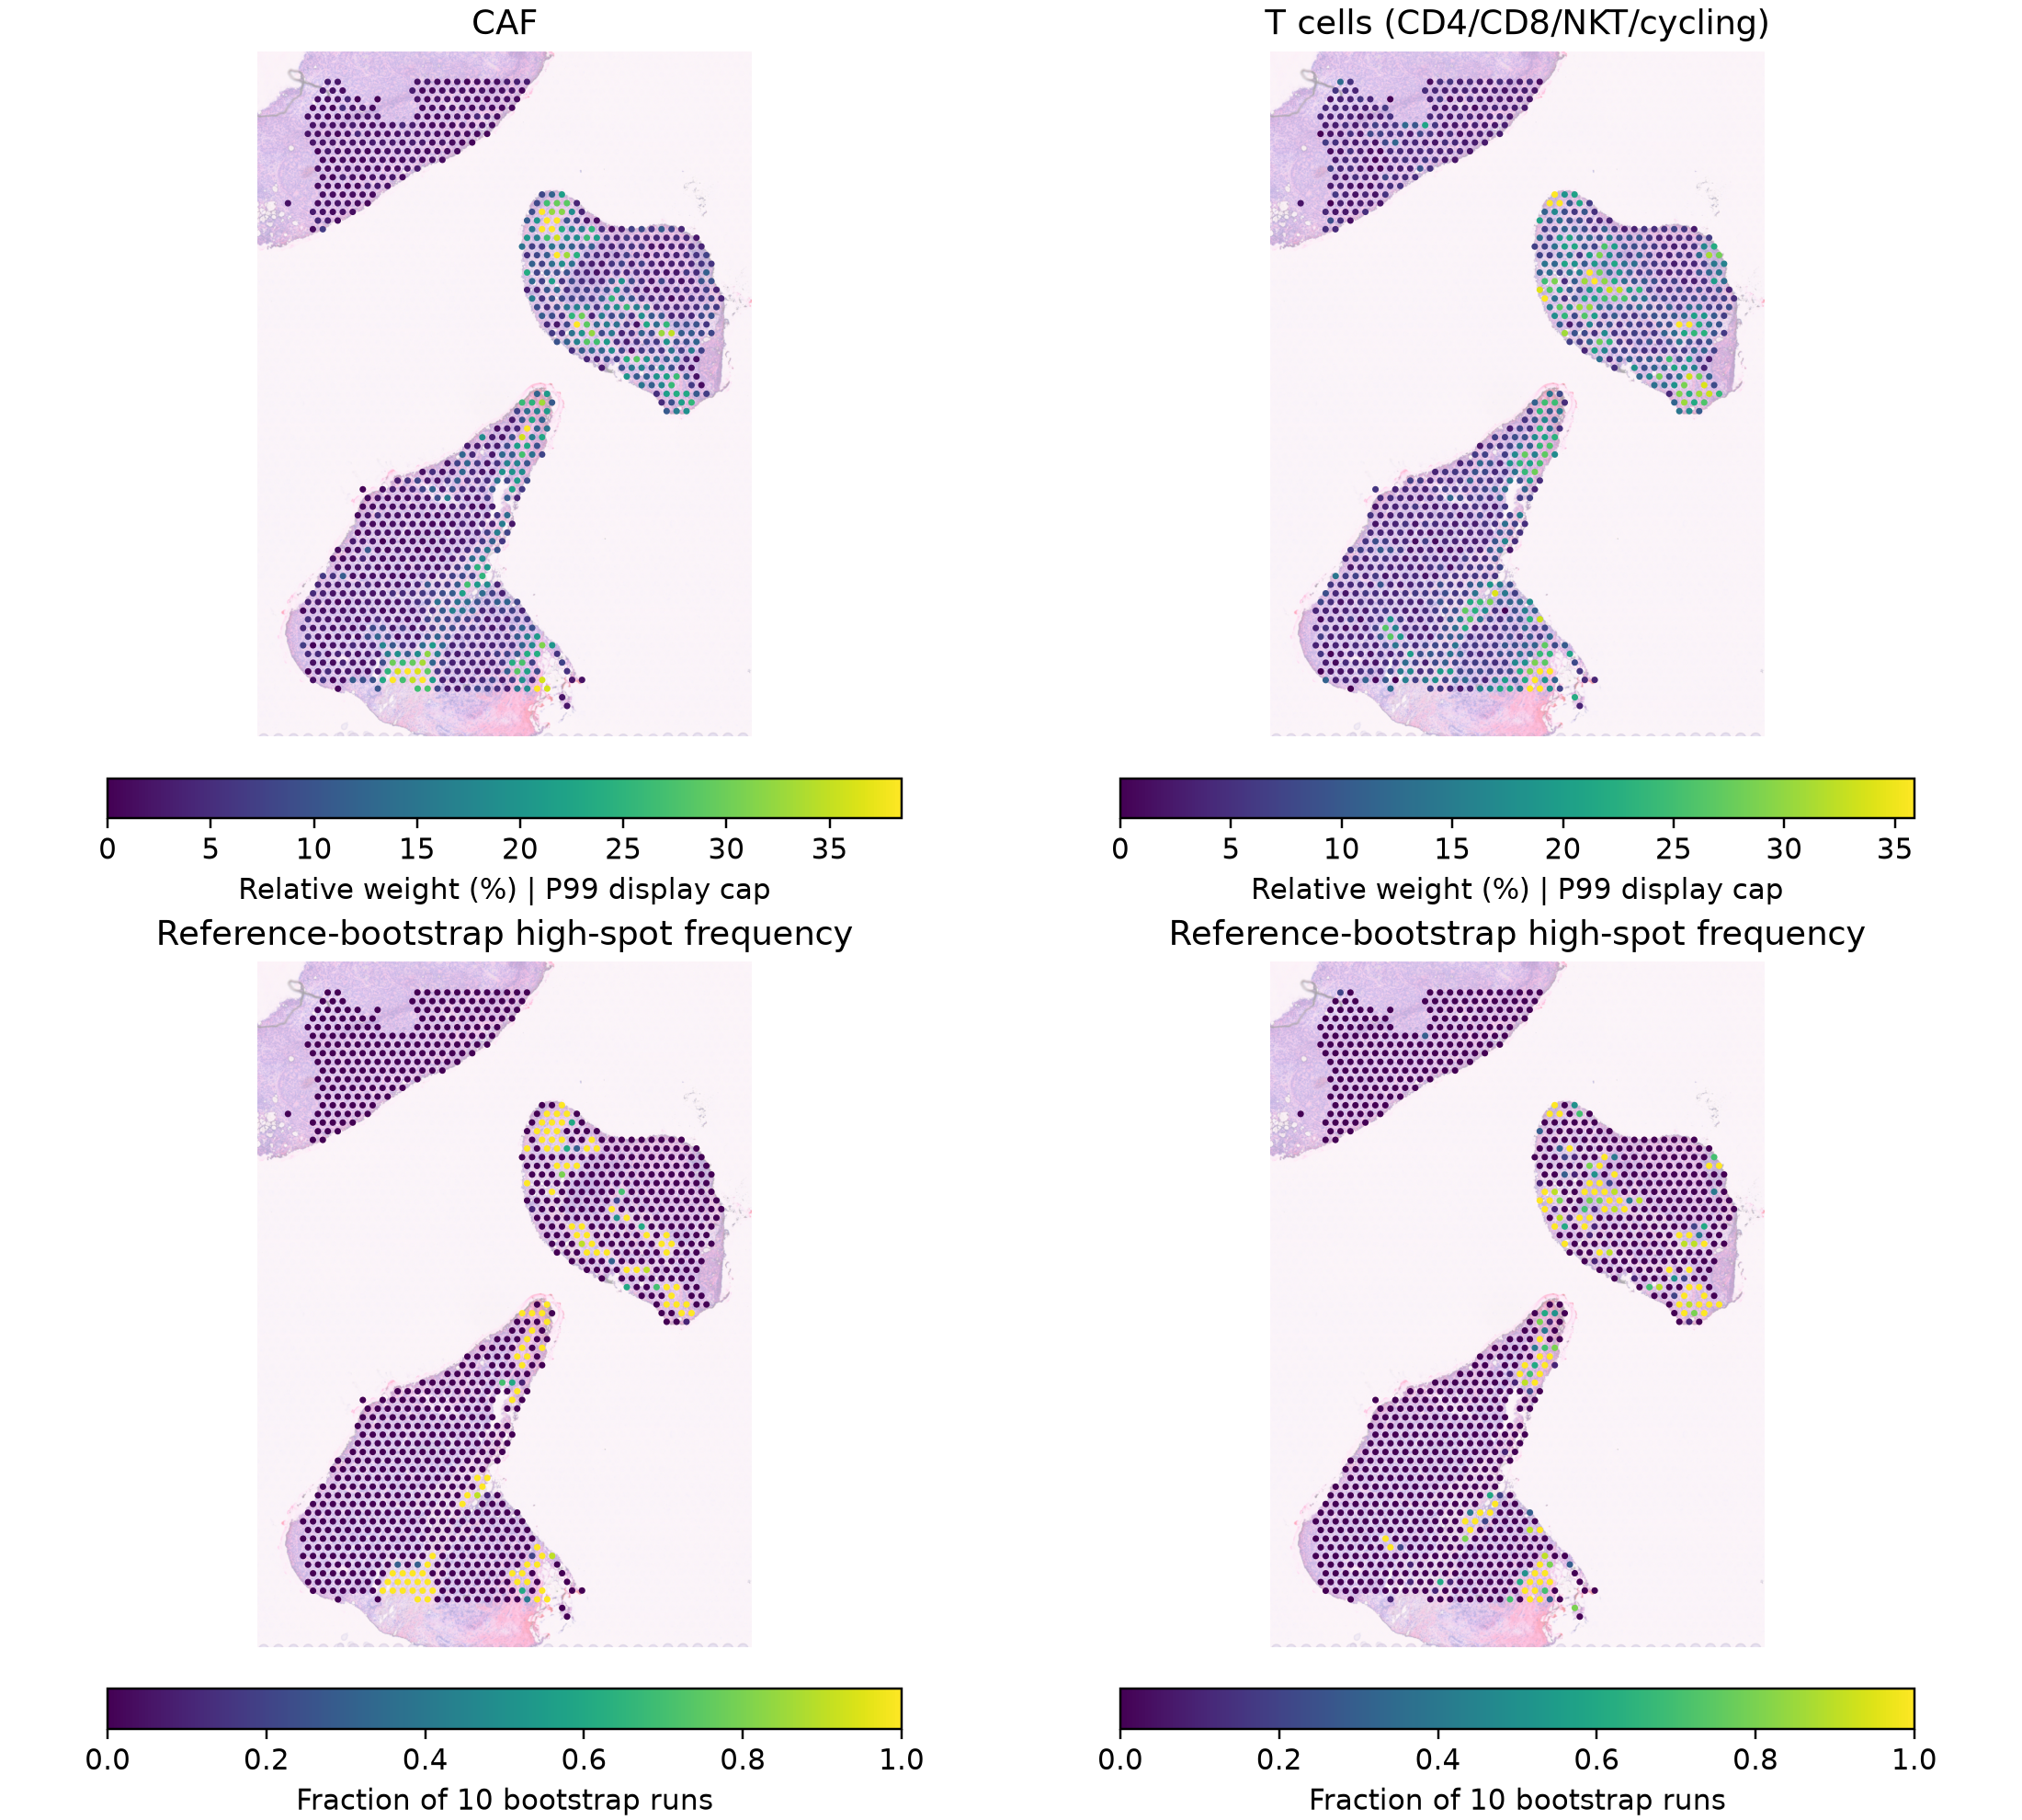

# CID4535的CAF与T细胞大类分布

空间图将原CID4535单供者参考的13类拟合结果相加，沿用1102个保留spot；没有重新拟合。它用于与原图逐点对照，和本轮两供者参考验证不是同一套拟合。
T cells由CD4、CD8、NKT和Cycling T组成，NK单独保留。上排为相对RNA权重，颜色上限使用各类型99%分位数；CSV保存未截断数值。下排为既有10次参考重抽样中进入该类型最高10% spot的频率。

- CAFs：平均空间排序相关0.995，前111个高权重spot平均保留95.9%。
- T cells：平均空间排序相关0.954，前111个高权重spot平均保留86.6%。

重抽样描述参考扰动下的稳定性，不是空间真值准确性。本图不用于CD8特异分布或CAF与CD8空间排斥的判断。


In [4]:
runpy.run_path(str(root / "src/sc_sncell_github/summarize_spatial_coarse_tcells.py"))
display(Image(filename=str(result_dir / "spatial_CID4535/CAF_T_spatial.png")))
display(Markdown((result_dir / "spatial_CID4535/interpretation.md").read_text()))


# 5. 核对与解读


In [5]:
runpy.run_path(str(root / "src/sc_sncell_github/validate_coarse_tcells.py"))
display(Markdown((result_dir / "interpretation.md").read_text()))


Checks: 97 / 97 max metric difference: 1.4210854715202004e-14


# T细胞粗分类比较

## 1. 分类与比较方式

将作者CD4、CD8、NKT和Cycling T合并为T cells，NK单独保留，其余类型不变，共10类。这里的T cells是这四个作者标签的操作性汇总，NKT标签未进一步解释为经TCR确认的特定亚群。
参考使用CID4471、CID4535的原12570个细胞，其中合并后的T细胞982个。本轮没有均衡供者，也没有删除低信息细胞。
比较两种方式：先用原13类模型拟合再相加；直接使用10类参考重新拟合。两个方法都以相加后的已知RNA份额和细胞份额评价。
复用此前五位供者的1502个模拟spot，未生成新的模拟组成。这些供者已经参与前期检查，本轮用于参考方案修订比较。

## 2. T细胞RNA份额误差

CID4067和CID4463使用原CAF/CD8混合配方；另外三位使用T细胞梯度及CAF背景配方。逐供者列出，不跨不同配方合并一个总体误差。单位为百分点。

| 供者 | 方法 | 深度 | 细分后汇总MAE | 粗分类重拟合MAE |
|---|---|---:|---:|---:|
| CID4067 | RCTD | 1 | 1.92 | 1.62 |
| CID4067 | RCTD | 0.25 | 2.34 | 2.02 |
| CID4067 | NNLS | 1 | 5.59 | 5.78 |
| CID4067 | NNLS | 0.25 | 5.90 | 5.83 |
| CID4463 | RCTD | 1 | 1.07 | 1.52 |
| CID4463 | RCTD | 0.25 | 1.19 | 1.58 |
| CID4463 | NNLS | 1 | 11.65 | 4.80 |
| CID4463 | NNLS | 0.25 | 11.52 | 4.71 |
| CID3941 | RCTD | 1 | 4.68 | 10.60 |
| CID3941 | RCTD | 0.25 | 6.21 | 12.72 |
| CID3941 | NNLS | 1 | 6.97 | 7.96 |
| CID3941 | NNLS | 0.25 | 6.73 | 8.32 |
| CID3948 | RCTD | 1 | 7.18 | 14.27 |
| CID3948 | RCTD | 0.25 | 8.24 | 15.14 |
| CID3948 | NNLS | 1 | 7.87 | 7.86 |
| CID3948 | NNLS | 0.25 | 8.36 | 8.64 |
| CID4461 | RCTD | 1 | 15.10 | 23.77 |
| CID4461 | RCTD | 0.25 | 18.27 | 26.33 |
| CID4461 | NNLS | 1 | 13.28 | 34.33 |
| CID4461 | NNLS | 0.25 | 13.58 | 39.60 |

## 3. 本轮采用的方式

当前采用细分拟合后汇总作为T细胞大类的输出方式。RCTD原深度下，五位供者中四位的T细胞MAE低于粗分类重拟合；CID4067是例外，重拟合为1.62个百分点，汇总为1.92。两个深度下这项排序一致。
CID3941、CID3948、CID4461的细分后汇总MAE分别为4.68、7.18、15.10个百分点；粗分类重拟合分别为10.60、14.27、23.77。直接用一个平均T细胞参考替代不同状态，并没有带来更好的定量。
纯CD8对照中，CID3948细分后汇总的平均T权重为87.8%，直接重拟合为61.6%；后者还将平均28.4%分配到NK。CID4461对应的T权重为68.2%和55.3%，低信息来源细胞的问题仍然存在。
CID4067纯NK对照中，细分后汇总仍平均给T细胞16.6%的权重，直接重拟合为6.2%。汇总解决的是T细胞内部标签分配对总量的影响，不能自动解决T与NK之间的误分配。
CAF指标在细分后汇总中保持原值；例如三位T细胞梯度供者的原深度CAF MAE分别为6.90、6.30和7.69个百分点。T细胞大类与原CD8是不同的评价对象，不能把两者MAE之差当成同一个目标准确性提高。

## 4. 纯群及缺失类型

pure_control_summary.csv保留原始纯群标签，分别查看CD4、CD8、NKT、Cycling T合并后的表现，以及NK是否被错误分配到T细胞。不能只看原有CD4/CD8互相混淆是否消失。
comparison_metrics.csv保存全部10类、各配方、两种真值和两个深度；caf_background_metrics.csv按CAF背景分别评价。
粗分类改变了研究对象：现在评价T细胞整体RNA贡献，不再把这项结果解释为CD8数量或CD8特异空间分布。

## 5. CID4535空间结果

spatial_CID4535目录保存原空间拟合的同定义汇总及CAF/T图。该图使用原CID4535单供者参考的1102个spot，与本轮双供者参考比较分开记录；没有据此宣称新参考的空间准确性已得到验证。
同时汇总既有10次参考重抽样，用于查看T细胞大类的分布稳定性。没有开展CAF/T因果或空间排斥判断。
